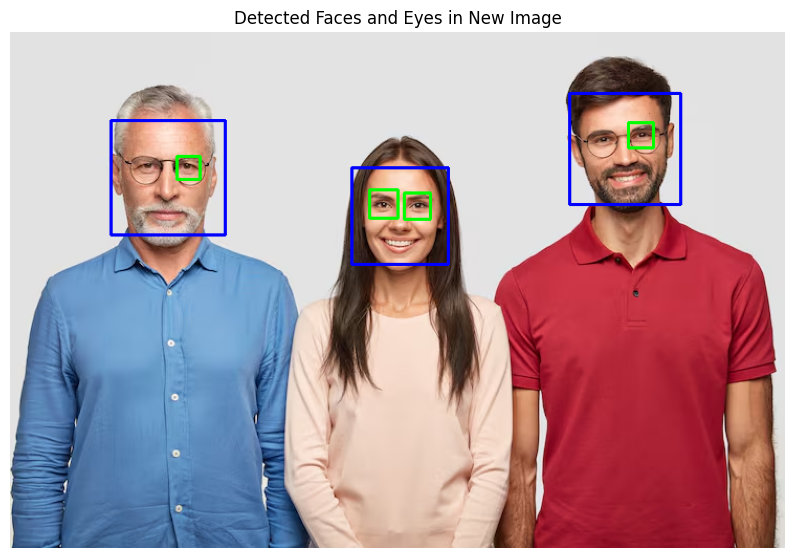

In [3]:
import cv2
import matplotlib.pyplot as plt

# Define the new image path
new_image_path = '/content/three-people-shot-serious-senior-male-pensioner-dressed-formal-shirt_273609-44787.png'

# Load the new image
image_new = cv2.imread(new_image_path)

# Check if the image was loaded successfully
if image_new is None:
    print(f"Error: Could not load image from {new_image_path}")
else:
    # Convert the image to grayscale
    gray_image_new = cv2.cvtColor(image_new, cv2.COLOR_BGR2GRAY)

    # Load the pre-trained Haar Cascade classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

    # Detect faces in the new image
    faces_new = face_cascade.detectMultiScale(gray_image_new, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Create a copy of the image to draw on
    image_display = image_new.copy()

    # Iterate over each detected face
    for (x, y, w, h) in faces_new:
        # Draw rectangle around the face
        cv2.rectangle(image_display, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle for faces

        # Extract the face region of interest (ROI) in grayscale and color
        roi_gray = gray_image_new[y:y+h, x:x+w]
        roi_color = image_display[y:y+h, x:x+w]

        # Detect eyes within the face ROI
        eyes_new = eye_cascade.detectMultiScale(roi_gray)

        # Draw rectangles around the detected eyes
        for (ex, ey, ew, eh) in eyes_new:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2) # Green rectangle for eyes

    # Display the image with detected faces and eyes
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image_display, cv2.COLOR_BGR2RGB))
    plt.title('Detected Faces and Eyes in New Image')
    plt.axis('off')
    plt.show()